# MVP1 de SSD - Classificação do Risco de Diabetes

**Disciplina:** Sistemas de Suporte à Decisão
**Universidade de Brasília (UnB)**
**Aluno:** Juliano Teles Abrahao - 231013411

Este notebook apresenta um MVP de classificação do **risco de diabetes** a partir de uma base de 15.000 pacientes com informações **demográficas, de estilo de vida, antropométricas, de sinais vitais e de exames laboratoriais**.

**Objetivo:** treinar e comparar modelos de Machine Learning para classificar o risco de diabetes de cada paciente em 3 categorias:

- **Baixo**
- **Moderado**
- **Alto**

---

## Definição do Problema

O problema é tratado como uma **classificação multiclasse**.

A variável `diabetes_risk` já vem rotulada na base em três níveis (`Low`, `Moderate`, `High`) e é convertida para um código ordinal:

- **0 – Baixo**
- **1 – Moderado**
- **2 – Alto**

A base é **desbalanceada** (aproximadamente 60% Baixo, 25% Moderado e 15% Alto), o que exige atenção à métrica de avaliação e ao balanceamento das classes durante o treino.

### Hipótese

Características de **estilo de vida, perfil socioeconômico, medidas antropométricas e sinais vitais** contêm informação suficiente para separar pacientes de risco baixo, moderado e alto **antes** da realização de exames laboratoriais.

Para testar essa hipótese, o notebook compara dois cenários de modelagem:

| Cenário | Features | Aplicação prática |
|---|---|---|
| **Triagem** | Sem exames laboratoriais (apenas questionário, medidas e sinais vitais) | Priorizar quem deve ser encaminhado para exame |
| **Clínico** | Com `fasting_blood_sugar` e `hba1c_level` | Estratificar risco após a coleta laboratorial |

> A comparação entre os dois cenários permite **quantificar o ganho de informação trazido pelos exames** e avaliar se uma triagem de baixo custo é viável.

O identificador `patient_id` é descartado, pois não carrega informação clínica e só introduziria ruído no modelo.

## 1. Configuração do Ambiente

In [1]:
# Execute esta célula no Google Colab.
# Se necessário:
# !pip install -q scikit-learn seaborn

import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# O notebook funciona no Google Colab (com upload) e também localmente.
try:
    from google.colab import files
    EXECUTANDO_NO_COLAB = True
except ImportError:
    EXECUTANDO_NO_COLAB = False

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# Garante que os gráficos sejam renderizados dentro do notebook e salvos no arquivo .ipynb,
# para que apareçam no GitHub sem precisar reexecutar.
%matplotlib inline

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
print("Ambiente configurado com sucesso.")
print("Executando no Colab:", EXECUTANDO_NO_COLAB)

Ambiente configurado com sucesso.
Executando no Colab: False


## 2. Carga e Preparação dos Dados

A base esperada (`diabetes_risk.csv`) deve conter, no mínimo, as colunas:

`patient_id`, `age`, `gender`, `city`, `bmi`, `family_history_diabetes`, `physical_activity_level`,
`diet_type`, `smoking_status`, `alcohol_consumption`, `hours_sleep_per_night`, `stress_level`,
`fasting_blood_sugar`, `hba1c_level`, `blood_pressure_systolic`, `blood_pressure_diastolic`,
`waist_circumference_cm`, `income_bracket`, `diabetes_risk`.

O arquivo **`diabetes_risk.csv` está versionado junto com este repositório**, portanto a célula abaixo o
carrega automaticamente quando o notebook é executado a partir da pasta do projeto.

No Google Colab, há duas formas de disponibilizar a base:

1. **Clonar o repositório** (a base vem junto):
   `!git clone https://github.com/<usuario>/<repositorio>.git` e depois
   `%cd <repositorio>`;
2. **Fazer upload manual** do arquivo — é o que a célula faz automaticamente caso não encontre a base
   no diretório de trabalho.

O notebook aceita arquivos `.csv`, `.xlsx` ou `.xls`.

In [2]:
# A base está versionada junto com este repositório.
ARQUIVO_PADRAO = "diabetes_risk.csv"

if os.path.exists(ARQUIVO_PADRAO):
    arquivo = ARQUIVO_PADRAO
    print(f"Base encontrada no diretório de trabalho: {arquivo}")
elif EXECUTANDO_NO_COLAB:
    print("Base não encontrada. Faça upload de diabetes_risk.csv:")
    uploaded = files.upload()
    arquivo = next(iter(uploaded.keys()))
else:
    raise FileNotFoundError(
        f"'{ARQUIVO_PADRAO}' não encontrado. Execute o notebook na pasta do repositório "
        "ou ajuste ARQUIVO_PADRAO para o caminho da base."
    )

if arquivo.lower().endswith((".xlsx", ".xls")):
    df_raw = pd.read_excel(arquivo)
elif arquivo.lower().endswith(".csv"):
    try:
        df_raw = pd.read_csv(arquivo)
    except Exception:
        df_raw = pd.read_csv(arquivo, sep=";")
else:
    raise ValueError("Formato não suportado. Utilize Excel ou CSV.")

print(f"Base carregada: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas")
display(df_raw.head())

Base encontrada no diretório de trabalho: diabetes_risk.csv
Base carregada: 15000 linhas x 19 colunas


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


### 2.1. Validação e limpeza

In [3]:
colunas_necessarias = [
    "age", "gender", "city", "bmi", "family_history_diabetes",
    "physical_activity_level", "diet_type", "smoking_status",
    "alcohol_consumption", "hours_sleep_per_night", "stress_level",
    "fasting_blood_sugar", "hba1c_level", "blood_pressure_systolic",
    "blood_pressure_diastolic", "waist_circumference_cm",
    "income_bracket", "diabetes_risk"
]

faltantes = [c for c in colunas_necessarias if c not in df_raw.columns]
if faltantes:
    raise ValueError(f"Colunas ausentes na base: {faltantes}")

df = df_raw.copy()

# Conversões numéricas
colunas_numericas = [
    "age", "bmi", "hours_sleep_per_night", "stress_level",
    "fasting_blood_sugar", "hba1c_level", "blood_pressure_systolic",
    "blood_pressure_diastolic", "waist_circumference_cm"
]
for coluna in colunas_numericas:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

linhas_iniciais = len(df)

# Remoção de pacientes duplicados
if "patient_id" in df.columns:
    df = df.drop_duplicates(subset="patient_id")

# Regras de plausibilidade clínica
df = df[df["age"].between(18, 95)]
df = df[df["bmi"] > 0]
df = df[df["fasting_blood_sugar"] > 0]
df = df[df["hba1c_level"] > 0]
df = df[df["blood_pressure_systolic"] > df["blood_pressure_diastolic"]]

# O alvo e as medidas numéricas não podem ser nulos
df = df.dropna(subset=colunas_numericas + ["diabetes_risk"]).copy()

print(f"Linhas iniciais: {linhas_iniciais}")
print(f"Linhas após limpeza: {len(df)}  (removidas: {linhas_iniciais - len(df)})")
display(df.head())

Linhas iniciais: 15000
Linhas após limpeza: 14998  (removidas: 2)


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


### 2.2. Valores ausentes

Três variáveis categóricas apresentam ausências:

- `smoking_status` e `income_bracket` — ausências aparentemente **aleatórias (MCAR)**;
- `alcohol_consumption` — ausência **relacionada ao próprio perfil do paciente (MNAR)**, concentrada em
  mulheres e pacientes mais velhos, provavelmente por subnotificação.

Como o padrão de ausência do consumo de álcool **não é aleatório**, descartar essas linhas removeria
justamente um subgrupo específico de pacientes e enviesaria a base. Por isso, a estratégia adotada é
**tratar a ausência como uma categoria própria** (`Nao informado`), preservando todos os registros e
permitindo que o modelo aprenda se o próprio "não informar" carrega sinal.

In [4]:
ausentes = df.isna().sum()
ausentes = ausentes[ausentes > 0].sort_values(ascending=False)

print("Valores ausentes por coluna:")
display(
    pd.DataFrame({
        "Ausentes": ausentes,
        "% da base": (ausentes / len(df) * 100).round(2)
    })
)

# Evidência de que a ausência de alcohol_consumption não é aleatória (MNAR)
if df["alcohol_consumption"].isna().any():
    df["_alcool_ausente"] = df["alcohol_consumption"].isna()

    print("\n% de ausência em alcohol_consumption por gênero:")
    print((df.groupby("gender")["_alcool_ausente"].mean() * 100).round(2))

    df["_faixa_etaria"] = pd.cut(df["age"], bins=[17, 40, 60, 95],
                                 labels=["18-40", "41-60", "61+"])
    print("\n% de ausência em alcohol_consumption por faixa etária:")
    print((df.groupby("_faixa_etaria", observed=True)["_alcool_ausente"].mean() * 100).round(2))

    df = df.drop(columns=["_alcool_ausente", "_faixa_etaria"])

# Ausência tratada como categoria explícita
colunas_categoricas_nulas = ["smoking_status", "alcohol_consumption", "income_bracket"]
for coluna in colunas_categoricas_nulas:
    df[coluna] = df[coluna].fillna("Nao informado")

print("\nAusentes restantes:", int(df.isna().sum().sum()))

Valores ausentes por coluna:


,Ausentes,% da base
alcohol_consumption,3787,25.25
smoking_status,472,3.15
income_bracket,463,3.09



% de ausência em alcohol_consumption por gênero:
gender
Female    41.32
Male      10.34
Other     17.65
Name: _alcool_ausente, dtype: float64

% de ausência em alcohol_consumption por faixa etária:
_faixa_etaria
18-40    24.59
41-60    24.30
61+      43.48
Name: _alcool_ausente, dtype: float64

Ausentes restantes: 0


## 3. Preparação da Variável Alvo

O alvo `diabetes_risk` vem como texto (`Low`, `Moderate`, `High`) e é convertido para um código ordinal,
que é o formato esperado pelos classificadores e pelas métricas do scikit-learn.

In [5]:
mapa_codigos = {"Low": 0, "Moderate": 1, "High": 2}
mapa_classes = {0: "Baixo", 1: "Moderado", 2: "Alto"}
ordem_classes = ["Baixo", "Moderado", "Alto"]

df["risco_codigo"] = df["diabetes_risk"].map(mapa_codigos)

if df["risco_codigo"].isna().any():
    valores_invalidos = df.loc[df["risco_codigo"].isna(), "diabetes_risk"].unique()
    raise ValueError(f"Valores de diabetes_risk fora de Low/Moderate/High: {valores_invalidos}")

df["risco_codigo"] = df["risco_codigo"].astype(int)
df["classe_nome"] = df["risco_codigo"].map(mapa_classes)

display(df[["age", "bmi", "hba1c_level", "fasting_blood_sugar",
            "diabetes_risk", "risco_codigo", "classe_nome"]].head(10))

,age,bmi,hba1c_level,fasting_blood_sugar,diabetes_risk,risco_codigo,classe_nome
0,47,26.5,7.3,178,Low,0,Baixo
1,53,20.5,6.9,152,Low,0,Baixo
2,47,31.3,6.6,168,High,2,Alto
3,41,22.8,6.7,155,Low,0,Baixo
4,57,16.7,6.7,188,Low,0,Baixo
5,58,22.0,6.3,148,Low,0,Baixo
6,42,22.5,7.5,190,Moderate,1,Moderado
7,42,19.5,8.9,270,High,2,Alto
8,57,20.3,7.4,186,Moderate,1,Moderado
9,44,24.1,7.6,178,Moderate,1,Moderado


### 3.1. Distribuição das classes

Distribuição absoluta:
classe_nome
Baixo       8998
Moderado    3750
Alto        2250
Name: count, dtype: int64

Distribuição percentual:
classe_nome
Baixo       59.99
Moderado    25.00
Alto        15.00
Name: count, dtype: float64

Baseline trivial (prever sempre a classe majoritária): 59.99% de acurácia


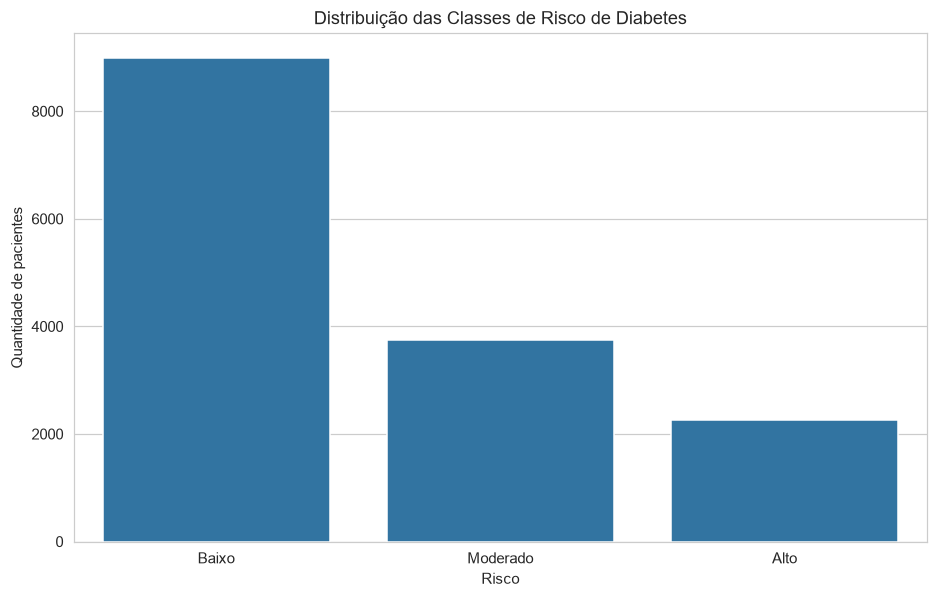

In [6]:
dist = df["classe_nome"].value_counts().reindex(ordem_classes)

print("Distribuição absoluta:")
print(dist)

print("\nDistribuição percentual:")
print((dist / len(df) * 100).round(2))

print(f"\nBaseline trivial (prever sempre a classe majoritária): {dist.max() / len(df):.2%} de acurácia")

sns.countplot(data=df, x="classe_nome", order=ordem_classes)
plt.title("Distribuição das Classes de Risco de Diabetes")
plt.xlabel("Risco")
plt.ylabel("Quantidade de pacientes")
plt.show()

## 4. Análise Exploratória

Antes da modelagem, verificamos como as variáveis clínicas e de estilo de vida se comportam entre as
três classes de risco. O objetivo é identificar quais variáveis realmente separam os grupos.

In [7]:
print("Resumo das variáveis numéricas:")
display(df[colunas_numericas].describe().T.round(2))

Resumo das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
age,14998.0,44.34,10.38,18.0,38.0,45.0,52.0,80.0
bmi,14998.0,23.06,4.05,15.0,20.1,22.7,25.6,40.8
hours_sleep_per_night,14998.0,7.31,1.11,3.0,6.7,7.0,8.0,12.0
stress_level,14998.0,5.94,2.15,1.0,4.0,6.0,7.0,10.0
fasting_blood_sugar,14998.0,168.80,38.36,72.0,145.0,165.0,189.0,400.0
hba1c_level,14998.0,6.88,0.84,4.8,6.3,6.8,7.3,13.4
blood_pressure_systolic,14998.0,139.50,12.65,80.0,130.0,140.0,150.0,200.0
blood_pressure_diastolic,14998.0,86.26,8.39,50.0,80.0,88.0,90.0,120.0
waist_circumference_cm,14998.0,100.21,10.76,73.2,92.5,99.3,106.9,148.2


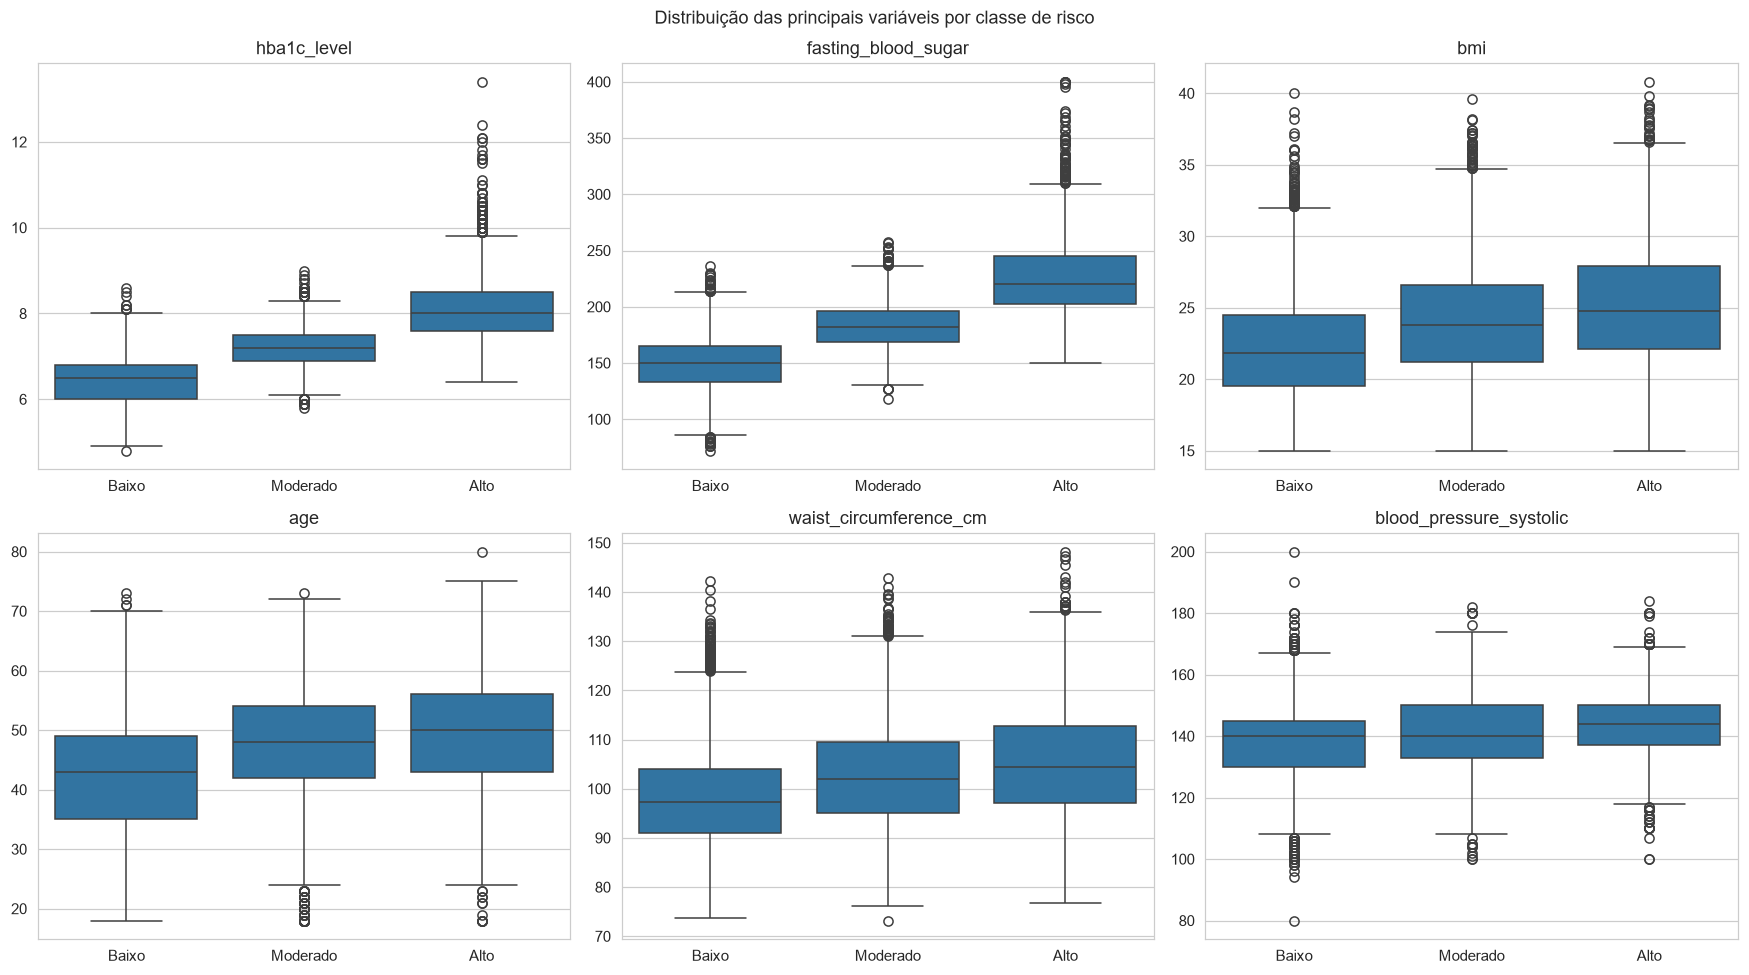

In [8]:
variaveis_boxplot = ["hba1c_level", "fasting_blood_sugar", "bmi", "age",
                     "waist_circumference_cm", "blood_pressure_systolic"]

fig, eixos = plt.subplots(2, 3, figsize=(16, 9))

for eixo, variavel in zip(eixos.ravel(), variaveis_boxplot):
    sns.boxplot(data=df, x="classe_nome", y=variavel, order=ordem_classes, ax=eixo)
    eixo.set_title(variavel)
    eixo.set_xlabel("")
    eixo.set_ylabel("")

fig.suptitle("Distribuição das principais variáveis por classe de risco")
plt.tight_layout()
plt.show()

In [9]:
# Perfil médio de cada classe
perfil_classes = (
    df.groupby("classe_nome")
      .agg(
          qtd=("risco_codigo", "size"),
          idade_mediana=("age", "median"),
          imc_mediano=("bmi", "median"),
          hba1c_mediano=("hba1c_level", "median"),
          glicemia_mediana=("fasting_blood_sugar", "median"),
          cintura_mediana=("waist_circumference_cm", "median"),
          estresse_medio=("stress_level", "mean"),
          sono_medio=("hours_sleep_per_night", "mean")
      )
      .reindex(ordem_classes)
      .round(2)
)

display(perfil_classes)

,qtd,idade_mediana,imc_mediano,hba1c_mediano,glicemia_mediana,cintura_mediana,estresse_medio,sono_medio
classe_nome,,,,,,,,
Baixo,8998,43.0,21.8,6.5,150.0,97.2,5.76,7.35
Moderado,3750,48.0,23.8,7.2,182.0,102.0,6.18,7.27
Alto,2250,50.0,24.8,8.0,220.0,104.5,6.27,7.23


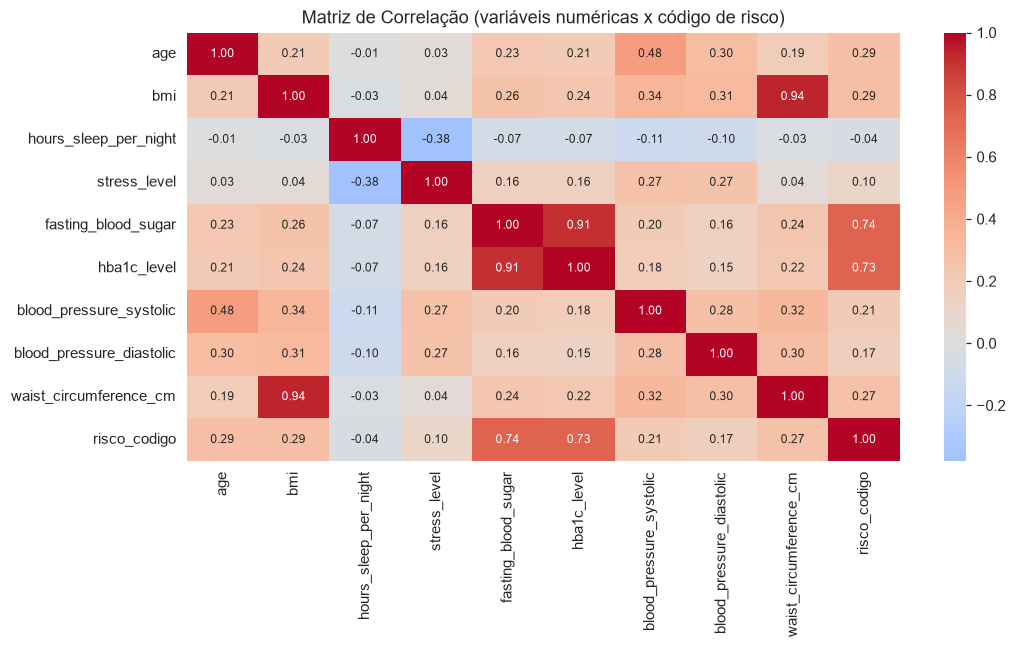

Correlação de cada variável com o risco:
fasting_blood_sugar         0.738
hba1c_level                 0.734
bmi                         0.289
age                         0.287
waist_circumference_cm      0.268
blood_pressure_systolic     0.212
blood_pressure_diastolic    0.167
stress_level                0.100
hours_sleep_per_night      -0.043
Name: risco_codigo, dtype: float64


In [10]:
# Correlação entre variáveis numéricas e o código de risco
colunas_correlacao = colunas_numericas + ["risco_codigo"]
matriz_correlacao = df[colunas_correlacao].corr()

sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, annot_kws={"size": 8})
plt.title("Matriz de Correlação (variáveis numéricas x código de risco)")
plt.tight_layout()
plt.show()

print("Correlação de cada variável com o risco:")
print(
    matriz_correlacao["risco_codigo"]
    .drop("risco_codigo")
    .sort_values(ascending=False)
    .round(3)
)

In [11]:
# Proporção de cada classe de risco dentro das variáveis categóricas
categoricas_exploracao = [
    "family_history_diabetes", "physical_activity_level",
    "smoking_status", "income_bracket"
]

for variavel in categoricas_exploracao:
    tabela = (
        pd.crosstab(df[variavel], df["classe_nome"], normalize="index")
        .reindex(columns=ordem_classes)
        .mul(100)
        .round(1)
    )
    print(f"\n% de cada classe de risco por {variavel}:")
    display(tabela)


% de cada classe de risco por family_history_diabetes:


classe_nome,Baixo,Moderado,Alto
family_history_diabetes,,,
No,65.8,21.7,12.5
Yes,49.1,31.2,19.7



% de cada classe de risco por physical_activity_level:


classe_nome,Baixo,Moderado,Alto
physical_activity_level,,,
Active,70.1,20.1,9.8
Moderate,59.1,26.5,14.4
Sedentary,50.5,28.5,21.0



% de cada classe de risco por smoking_status:


classe_nome,Baixo,Moderado,Alto
smoking_status,,,
Current,59.8,25.7,14.5
Former,59.1,26.7,14.2
Nao informado,58.1,27.3,14.6
Never,60.3,24.5,15.3



% de cada classe de risco por income_bracket:


classe_nome,Baixo,Moderado,Alto
income_bracket,,,
High,57.4,25.9,16.6
Low,61.5,23.9,14.6
Middle,60.8,25.2,14.1
Nao informado,58.1,23.1,18.8


## 5. Preparação para Machine Learning

### Features

**Categóricas (ambos os cenários)**

- `gender`, `city`, `family_history_diabetes`, `physical_activity_level`,
  `diet_type`, `smoking_status`, `alcohol_consumption`, `income_bracket`

**Numéricas — Cenário Triagem (sem exames laboratoriais)**

- `age`, `bmi`, `hours_sleep_per_night`, `stress_level`, `waist_circumference_cm`,
  `blood_pressure_systolic`, `blood_pressure_diastolic`

**Numéricas — Cenário Clínico (com exames)**

- todas as anteriores **+** `fasting_blood_sugar` e `hba1c_level`

### Target

`risco_codigo` (0 = Baixo, 1 = Moderado, 2 = Alto)

O modelo **não recebe**:

- `patient_id` — identificador sem valor clínico;
- `diabetes_risk` e `classe_nome` — são o próprio alvo em outro formato.

In [12]:
features_categoricas = [
    "gender", "city", "family_history_diabetes", "physical_activity_level",
    "diet_type", "smoking_status", "alcohol_consumption", "income_bracket"
]

features_numericas_triagem = [
    "age", "bmi", "hours_sleep_per_night", "stress_level",
    "waist_circumference_cm", "blood_pressure_systolic",
    "blood_pressure_diastolic"
]

features_numericas_clinico = features_numericas_triagem + [
    "fasting_blood_sugar", "hba1c_level"
]

cenarios = {
    "Triagem (sem exames)": features_numericas_triagem,
    "Clinico (com exames)": features_numericas_clinico
}

y = df["risco_codigo"].copy()

for nome_cenario, numericas in cenarios.items():
    print(f"{nome_cenario}: {len(features_categoricas) + len(numericas)} features")

print("\nTarget: risco_codigo")
print("Distribuição do target:")
print(y.value_counts(normalize=True).sort_index().round(3))

Triagem (sem exames): 15 features
Clinico (com exames): 17 features

Target: risco_codigo
Distribuição do target:
risco_codigo
0    0.60
1    0.25
2    0.15
Name: proportion, dtype: float64


### 5.1. Separação treino/teste

A divisão é **estratificada**, garantindo que a proporção 60/25/15 das classes seja mantida em treino e
teste. Os dois cenários usam a mesma semente e a mesma estratificação, portanto **os mesmos pacientes**
caem em treino e teste nos dois casos — o que torna a comparação entre eles justa.

In [13]:
dados_cenarios = {}

for nome_cenario, numericas in cenarios.items():
    X = df[features_categoricas + numericas].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )

    dados_cenarios[nome_cenario] = {
        "numericas": numericas,
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test
    }

    print(f"{nome_cenario} -> treino: {len(X_train)} | teste: {len(X_test)}")

print("\nProporção das classes no treino:")
print(dados_cenarios["Clinico (com exames)"]["y_train"].value_counts(normalize=True).sort_index().round(3))
print("\nProporção das classes no teste:")
print(dados_cenarios["Clinico (com exames)"]["y_test"].value_counts(normalize=True).sort_index().round(3))

Triagem (sem exames) -> treino: 11998 | teste: 3000


Clinico (com exames) -> treino: 11998 | teste: 3000

Proporção das classes no treino:
risco_codigo
0    0.60
1    0.25
2    0.15
Name: proportion, dtype: float64

Proporção das classes no teste:
risco_codigo
0    0.60
1    0.25
2    0.15
Name: proportion, dtype: float64


### 5.2. Pipeline de pré-processamento

O pré-processamento é encapsulado em um `ColumnTransformer` dentro de um `Pipeline`. Isso garante que a
padronização e a codificação sejam **ajustadas apenas no treino** e apenas aplicadas no teste, evitando
vazamento de informação.

- **Numéricas:** `StandardScaler` (necessário para a Regressão Logística convergir);
- **Categóricas:** `OneHotEncoder` com `handle_unknown="ignore"`, para tolerar categorias inéditas.

In [14]:
def criar_preprocessador(features_numericas):
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), features_numericas),
            ("cat", OneHotEncoder(handle_unknown="ignore"), features_categoricas)
        ]
    )

print("Função de pré-processamento criada.")

Função de pré-processamento criada.


## 6. Modelagem

Serão comparados três modelos, **em cada um dos dois cenários**:

1. **Dummy Classifier** — baseline mínimo (prevê sempre a classe majoritária);
2. **Regressão Logística Multinomial** — baseline supervisionado e interpretável;
3. **Random Forest Classifier** — modelo principal, capaz de capturar relações não lineares e interações.

Como a base é desbalanceada, os modelos supervisionados usam `class_weight="balanced"`, que aumenta o
peso das classes minoritárias (Moderado e Alto) durante o treino.

In [15]:
def construir_modelos():
    return {
        "Dummy Baseline": DummyClassifier(strategy="most_frequent"),
        "Regressão Logística": LogisticRegression(
            max_iter=2500,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    }

pipelines = {}
resultados = []

for nome_cenario, dados in dados_cenarios.items():
    for nome_modelo, modelo in construir_modelos().items():
        pipeline = Pipeline([
            ("preprocessor", criar_preprocessador(dados["numericas"])),
            ("classifier", modelo)
        ])

        pipeline.fit(dados["X_train"], dados["y_train"])
        pred = pipeline.predict(dados["X_test"])

        pipelines[(nome_cenario, nome_modelo)] = pipeline

        resultados.append({
            "Cenário": nome_cenario,
            "Modelo": nome_modelo,
            "Acurácia": accuracy_score(dados["y_test"], pred),
            "Precisão Ponderada": precision_score(dados["y_test"], pred, average="weighted", zero_division=0),
            "Recall Ponderado": recall_score(dados["y_test"], pred, average="weighted", zero_division=0),
            "F1 Ponderado": f1_score(dados["y_test"], pred, average="weighted", zero_division=0),
            "F1 Macro": f1_score(dados["y_test"], pred, average="macro", zero_division=0)
        })

results_df = pd.DataFrame(resultados).set_index(["Cenário", "Modelo"])
display(results_df.round(4))

Acurácia  Precisão Ponderada  \
Cenário              Modelo                                              
Triagem (sem exames) Dummy Baseline         0.6000              0.3600   
                     Regressão Logística    0.5257              0.5714   
                     Random Forest          0.5917              0.5724   
Clinico (com exames) Dummy Baseline         0.6000              0.3600   
                     Regressão Logística    0.7667              0.7952   
                     Random Forest          0.7737              0.7937   

                                          Recall Ponderado  F1 Ponderado  \
Cenário              Modelo                                                
Triagem (sem exames) Dummy Baseline                 0.6000        0.4500   
                     Regressão Logística            0.5257        0.5397   
                     Random Forest                  0.5917        0.5800   
Clinico (com exames) Dummy Baseline                 0.6000        0.4500   
                     Regressão Logística            0.7667        0.7761   
                     Random Forest                  0.7737        0.7807   

                                          F1 Macro  
Cenário              Modelo                         
Triagem (sem exames) Dummy Baseline         0.2500  
                     Regressão Logística    0.4394  
                     Random Forest          0.4617  
Clinico (com exames) Dummy Baseline         0.2500  
                     Regressão Logística    0.7374  
                     Random Forest          0.7379

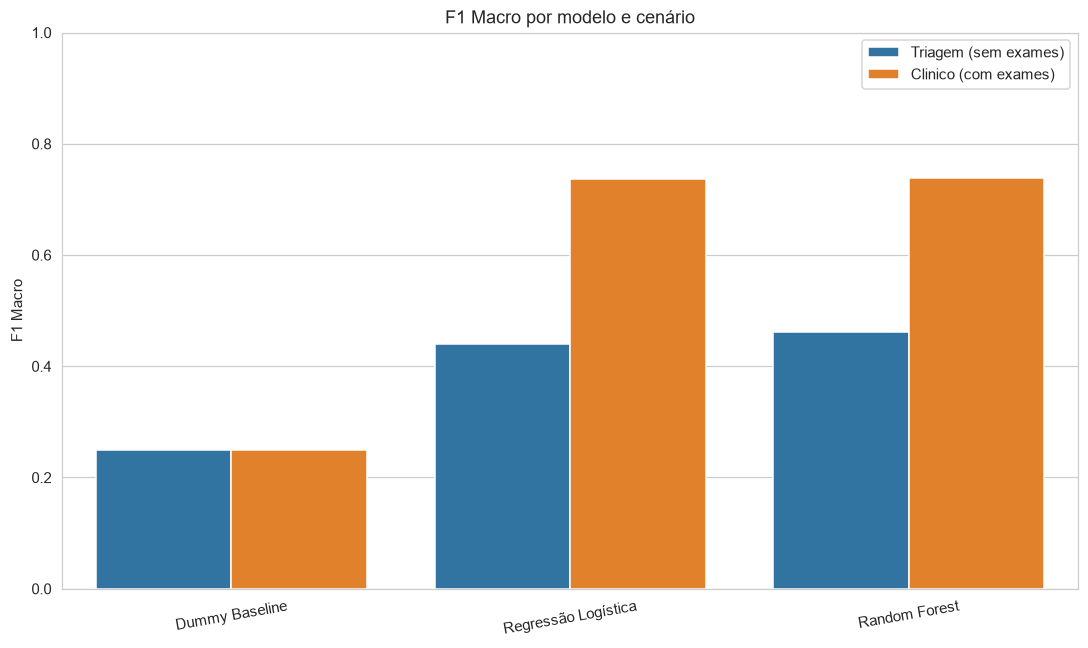

In [16]:
grafico = results_df.reset_index()

sns.barplot(data=grafico, x="Modelo", y="F1 Macro", hue="Cenário")
plt.title("F1 Macro por modelo e cenário")
plt.ylabel("F1 Macro")
plt.xlabel("")
plt.xticks(rotation=10)
plt.ylim(0, 1)
plt.legend(title="")
plt.tight_layout()
plt.show()

### Por que usar F1 Macro?

As três classes têm tamanhos bem diferentes (60% / 25% / 15%). Um modelo que simplesmente prevê sempre
"Baixo" já atinge **60% de acurácia** sem acertar um único paciente de risco Alto — que é exatamente o
grupo que mais importa em um sistema de apoio à decisão clínica.

O **F1 Macro** dá o mesmo peso às três classes e, por isso, penaliza esse comportamento. É a métrica
principal de comparação neste MVP.

### Leitura da comparação entre cenários

A diferença entre os dois cenários é o resultado mais relevante deste MVP: ela mede, em termos de F1
Macro, **quanto os exames laboratoriais acrescentam** ao que já se sabe pelo questionário e pelas
medidas de consultório.

Note também que, no cenário de Triagem, os modelos supervisionados podem ficar **abaixo do Dummy em
acurácia** e ainda assim **muito acima em F1 Macro**. Isso não é uma contradição: com
`class_weight="balanced"`, o modelo troca acertos na classe majoritária por acertos nas classes
Moderado e Alto — exatamente o comportamento desejado em triagem.

## 7. Otimização do Random Forest

A otimização é feita no **cenário Clínico**, que apresentou o melhor desempenho. O `GridSearchCV` usa
validação cruzada de 5 folds sobre o conjunto de treino, otimizando diretamente o F1 Macro.

In [17]:
dados_clinico = dados_cenarios["Clinico (com exames)"]

pipeline_rf = Pipeline([
    ("preprocessor", criar_preprocessador(dados_clinico["numericas"])),
    ("classifier", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [8, 14, None],
    "classifier__min_samples_leaf": [1, 5, 20]
}

grid = GridSearchCV(
    pipeline_rf,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(dados_clinico["X_train"], dados_clinico["y_train"])

rf_otimizado = grid.best_estimator_

print("\nMelhores parâmetros:")
print(grid.best_params_)
print(f"Melhor F1 Macro na validação cruzada: {grid.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits



Melhores parâmetros:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 400}
Melhor F1 Macro na validação cruzada: 0.7443


## 8. Avaliação Final

In [18]:
X_train = dados_clinico["X_train"]
X_test = dados_clinico["X_test"]
y_train = dados_clinico["y_train"]
y_test = dados_clinico["y_test"]

pred_otimizado = rf_otimizado.predict(X_test)

metricas_otimizado = pd.DataFrame({
    "Métrica": ["Acurácia", "Precisão Ponderada", "Recall Ponderado", "F1 Ponderado", "F1 Macro"],
    "Valor": [
        accuracy_score(y_test, pred_otimizado),
        precision_score(y_test, pred_otimizado, average="weighted", zero_division=0),
        recall_score(y_test, pred_otimizado, average="weighted", zero_division=0),
        f1_score(y_test, pred_otimizado, average="weighted", zero_division=0),
        f1_score(y_test, pred_otimizado, average="macro", zero_division=0)
    ]
})

display(metricas_otimizado.round(4))

print("\nRelatório de classificação:")
print(classification_report(
    y_test,
    pred_otimizado,
    labels=[0, 1, 2],
    target_names=ordem_classes,
    zero_division=0
))

,Métrica,Valor
0,Acurácia,0.7750
1,Precisão Ponderada,0.7943
2,Recall Ponderado,0.7750
3,F1 Ponderado,0.7817
4,F1 Macro,0.7383



Relatório de classificação:
              precision    recall  f1-score   support

       Baixo       0.90      0.83      0.86      1800
    Moderado       0.55      0.68      0.60       750
        Alto       0.80      0.70      0.75       450

    accuracy                           0.78      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.79      0.78      0.78      3000



### 8.1. Matriz de Confusão

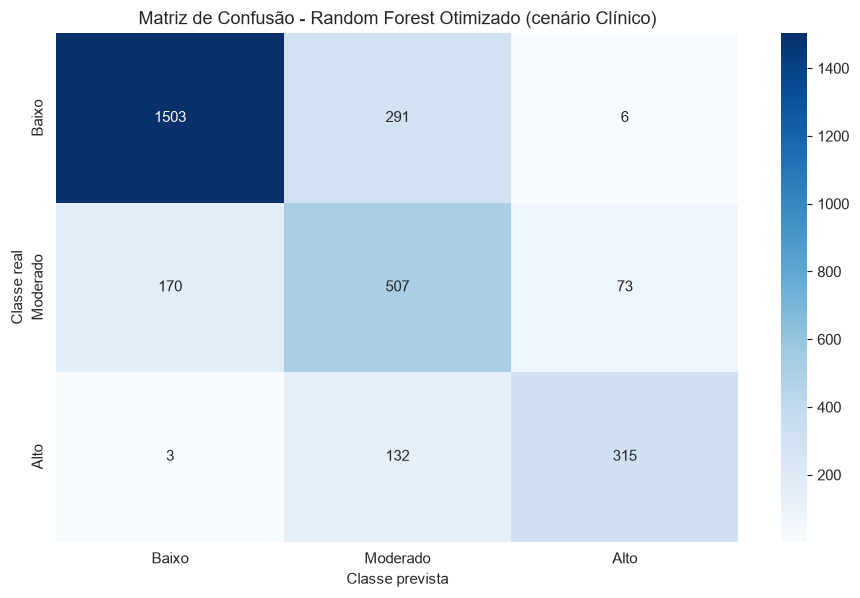

Pacientes de risco Alto classificados como Baixo: 3
Pacientes de risco Baixo classificados como Alto: 6

Obs.: em triagem clínica, classificar um paciente de risco Alto como Baixo é o erro mais custoso.


In [19]:
cm = confusion_matrix(y_test, pred_otimizado, labels=[0, 1, 2])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=ordem_classes,
    yticklabels=ordem_classes
)
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.title("Matriz de Confusão - Random Forest Otimizado (cenário Clínico)")
plt.show()

# Erros graves: confundir risco Alto com Baixo (e vice-versa)
print(f"Pacientes de risco Alto classificados como Baixo: {int(cm[2, 0])}")
print(f"Pacientes de risco Baixo classificados como Alto: {int(cm[0, 2])}")
print("\nObs.: em triagem clínica, classificar um paciente de risco Alto como Baixo é o erro mais custoso.")

### 8.2. Análise de Overfitting

In [20]:
acc_treino = rf_otimizado.score(X_train, y_train)
acc_teste = rf_otimizado.score(X_test, y_test)

print(f"Acurácia treino: {acc_treino:.4f}")
print(f"Acurácia teste:  {acc_teste:.4f}")
print(f"Diferença:       {acc_treino - acc_teste:.4f}")

if acc_treino - acc_teste > 0.10:
    print("Possível overfitting: a diferença entre treino e teste é relevante.")
else:
    print("Não há indicação forte de overfitting pelo critério adotado.")

Acurácia treino: 0.9999
Acurácia teste:  0.7750
Diferença:       0.2249
Possível overfitting: a diferença entre treino e teste é relevante.


**Interpretação.** O `GridSearchCV` escolheu uma floresta **sem restrição de profundidade**
(`max_depth=None`, `min_samples_leaf=1`), que praticamente memoriza o conjunto de treino. A diferença
entre treino e teste é grande, mas o desempenho **em teste** dessa configuração ainda foi o melhor na
validação cruzada — inclusive superior ao das alternativas mais regularizadas testadas no grid
(`max_depth` 8 e 14, `min_samples_leaf` 5 e 20).

Esse é um comportamento típico de Random Forest: cada árvore individual memoriza, mas a média sobre 400
árvores com amostragem bootstrap controla a variância. O que importa para a decisão de modelo é a
métrica no conjunto de teste, não a distância até a acurácia de treino.

Ainda assim, o resultado indica que **o teto do problema já foi atingido com estas features**: o ruído
irredutível da base impede que o modelo passe de aproximadamente 0,74 de F1 Macro, por mais complexo
que fique.

## 9. Importância das Variáveis

,Feature,Importância
0,num__fasting_blood_sugar,0.258871
1,num__hba1c_level,0.216939
2,num__age,0.064643
3,num__bmi,0.057806
4,num__waist_circumference_cm,0.056425
5,num__blood_pressure_systolic,0.039487
6,num__blood_pressure_diastolic,0.034061
7,num__hours_sleep_per_night,0.031908
8,num__stress_level,0.029171
9,cat__income_bracket_Middle,0.008228


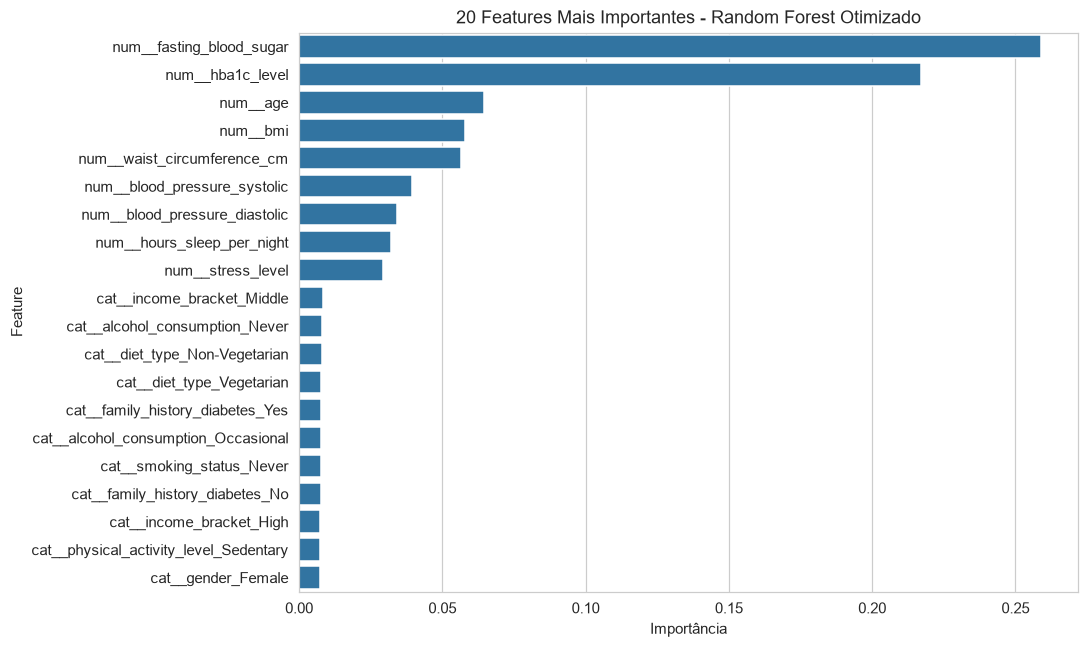

In [21]:
feature_names = (
    rf_otimizado
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importancias = (
    rf_otimizado
    .named_steps["classifier"]
    .feature_importances_
)

imp_df = (
    pd.DataFrame({"Feature": feature_names, "Importância": importancias})
      .sort_values("Importância", ascending=False)
      .reset_index(drop=True)
)

display(imp_df.head(20))

sns.barplot(data=imp_df.head(20), x="Importância", y="Feature")
plt.title("20 Features Mais Importantes - Random Forest Otimizado")
plt.tight_layout()
plt.show()

,Importância acumulada
Variavel,
fasting_blood_sugar,0.2589
hba1c_level,0.2169
city,0.0663
age,0.0646
bmi,0.0578
waist_circumference_cm,0.0564
blood_pressure_systolic,0.0395
blood_pressure_diastolic,0.0341
hours_sleep_per_night,0.0319


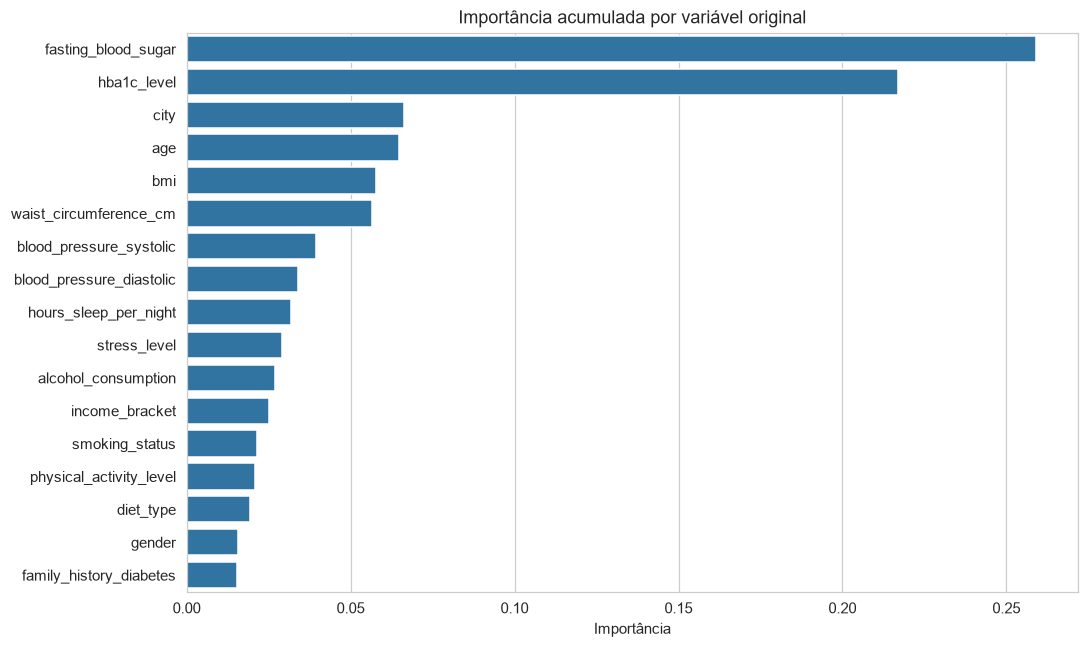

In [22]:
# Importância agregada por variável original (soma das colunas geradas pelo one-hot)
def variavel_original(nome_feature):
    nome = nome_feature.split("__", 1)[-1]
    for coluna in features_categoricas:
        if nome.startswith(coluna + "_"):
            return coluna
    return nome

imp_agrupada = (
    imp_df.assign(Variavel=imp_df["Feature"].map(variavel_original))
          .groupby("Variavel")["Importância"]
          .sum()
          .sort_values(ascending=False)
          .round(4)
)

display(imp_agrupada.to_frame("Importância acumulada"))

sns.barplot(x=imp_agrupada.values, y=imp_agrupada.index)
plt.title("Importância acumulada por variável original")
plt.xlabel("Importância")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Cuidado na leitura da importância.** A importância por impureza do Random Forest é **enviesada a favor
de variáveis com muitos valores distintos**. A variável `city`, por exemplo, gera 18 colunas no one-hot
e acumula uma importância relativamente alta, embora a análise exploratória não tenha mostrado
diferença relevante de risco entre cidades — o modelo está encontrando divisões em ruído.

Variáveis contínuas como `fasting_blood_sugar` e `hba1c_level` também se beneficiam desse viés, mas no
caso delas a correlação direta com o alvo (0,74 para ambas) confirma que o sinal é real.

## 10. Análise dos Erros

In [23]:
analise = X_test.copy()
analise["classe_real"] = y_test.values
analise["classe_prevista"] = pred_otimizado
analise["acerto"] = analise["classe_real"] == analise["classe_prevista"]

analise["classe_real_nome"] = analise["classe_real"].map(mapa_classes)
analise["classe_prevista_nome"] = analise["classe_prevista"].map(mapa_classes)

print("Acertos e erros:")
print(analise["acerto"].value_counts())
print(f"\nTaxa de acerto: {analise['acerto'].mean():.2%}")

print("\nTaxa de acerto por classe real:")
print(analise.groupby("classe_real_nome")["acerto"].mean().reindex(ordem_classes).round(3))

print("\nExemplos de erros:")
display(
    analise.loc[
        ~analise["acerto"],
        [
            "age", "bmi", "hba1c_level", "fasting_blood_sugar",
            "family_history_diabetes", "physical_activity_level",
            "classe_real_nome", "classe_prevista_nome"
        ]
    ].head(15)
)

Acertos e erros:
acerto
True     2325
False     675
Name: count, dtype: int64

Taxa de acerto: 77.50%

Taxa de acerto por classe real:
classe_real_nome
Baixo       0.835
Moderado    0.676
Alto        0.700
Name: acerto, dtype: float64

Exemplos de erros:


,age,bmi,hba1c_level,fasting_blood_sugar,family_history_diabetes,physical_activity_level,classe_real_nome,classe_prevista_nome
115,47,23.2,7.3,175,Yes,Sedentary,Baixo,Moderado
2513,48,22.7,6.2,155,No,Moderate,Moderado,Baixo
7734,52,26.7,7.5,189,No,Sedentary,Alto,Moderado
10651,55,29.6,6.9,177,No,Sedentary,Baixo,Moderado
14901,49,19.2,7.9,198,No,Moderate,Alto,Moderado
4255,35,28.6,7.9,192,Yes,Sedentary,Alto,Moderado
9041,57,17.0,6.9,160,Yes,Active,Moderado,Baixo
566,33,22.4,7.0,180,Yes,Active,Alto,Moderado
1893,60,25.2,7.2,181,No,Active,Baixo,Moderado
2261,58,19.5,6.7,174,No,Sedentary,Baixo,Moderado


,qtd,idade_media,imc_medio,hba1c_medio,glicemia_media
acerto,,,,,
Erros,675,47.05,23.87,7.15,181.55
Acertos,2325,43.25,22.65,6.81,164.88


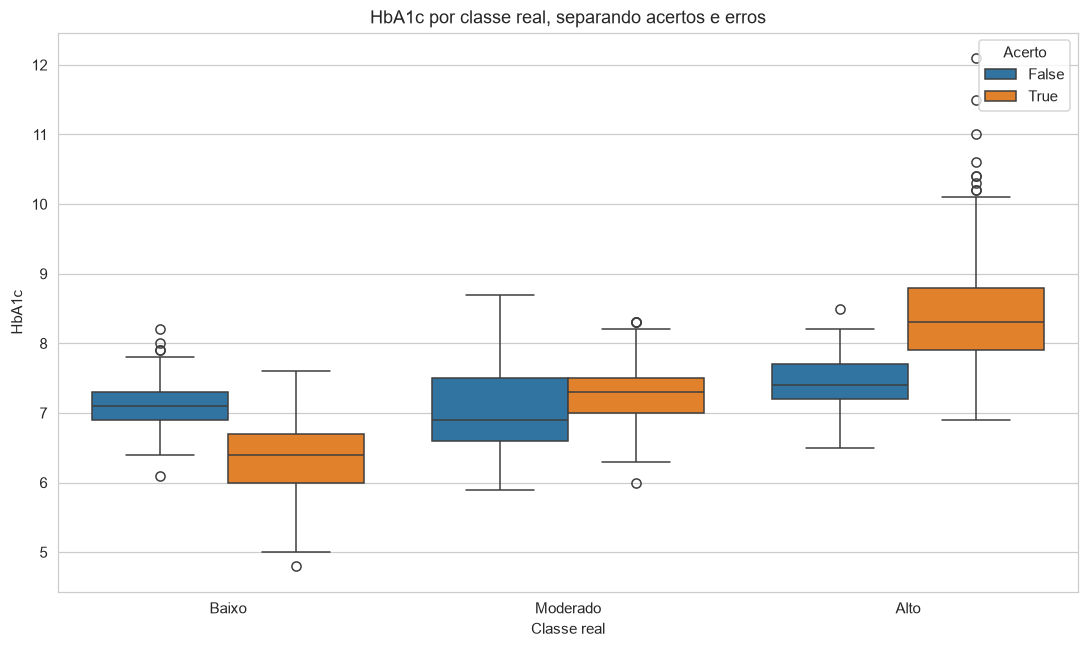

In [24]:
# Onde estão os erros? Comparação do perfil de acertos e erros
comparativo_erros = (
    analise.groupby("acerto")
           .agg(
               qtd=("age", "size"),
               idade_media=("age", "mean"),
               imc_medio=("bmi", "mean"),
               hba1c_medio=("hba1c_level", "mean"),
               glicemia_media=("fasting_blood_sugar", "mean")
           )
           .round(2)
)
comparativo_erros.index = comparativo_erros.index.map({True: "Acertos", False: "Erros"})

display(comparativo_erros)

sns.boxplot(data=analise, x="classe_real_nome", y="hba1c_level",
            hue="acerto", order=ordem_classes)
plt.title("HbA1c por classe real, separando acertos e erros")
plt.xlabel("Classe real")
plt.ylabel("HbA1c")
plt.legend(title="Acerto")
plt.tight_layout()
plt.show()

## 11. Conclusão

Este MVP trata a base de pacientes como um problema de **classificação multiclasse de risco de diabetes**,
comparando dois cenários de uso realistas em um sistema de suporte à decisão clínica.

### Principais achados

1. **Os exames laboratoriais são determinantes.** O cenário Clínico (com `hba1c_level` e
   `fasting_blood_sugar`) alcança um F1 Macro muito superior ao cenário de Triagem, e as duas variáveis
   laboratoriais concentram a maior parte da importância do Random Forest.

2. **Sem exames, a triagem tem poder preditivo limitado.** No cenário de Triagem os modelos superam
   claramente o baseline em F1 Macro — ou seja, conseguem identificar parte dos pacientes de risco
   Moderado e Alto —, mas ficam longe do desempenho obtido com exames. O questionário e as medidas de
   consultório, sozinhos, **não substituem** a coleta laboratorial; servem como priorização de fila.

3. **O desbalanceamento importa mais que a acurácia.** Prever sempre "Baixo" já entrega 60% de acurácia
   com F1 Macro de apenas 0,25. Esse contraste justifica a escolha do F1 Macro como métrica principal.

4. **Regressão Logística e Random Forest ficam próximos no cenário Clínico**, o que é coerente com a
   estrutura do problema: o risco cresce de forma majoritariamente monotônica com HbA1c e glicemia.
   O ganho do Random Forest vem das interações (idade × IMC, histórico familiar × exames).

5. **A classe Moderado é a mais difícil.** Praticamente todos os erros estão nas fronteiras
   Baixo↔Moderado e Moderado↔Alto — os erros graves (Alto previsto como Baixo) são pouquíssimos. Isso é
   exatamente o que se espera de uma variável de risco definida por faixas de uma escala contínua, e é
   uma boa notícia do ponto de vista clínico: o modelo erra de grau, não de direção.

6. **A otimização trouxe pouco ganho.** O F1 Macro do Random Forest praticamente não mudou após o
   `GridSearchCV`, sinalizando que o limite do problema com estas features já havia sido atingido. Mais
   capacidade de modelo não compensa a falta de informação nos dados.

### Aplicações

- **priorização de exames** em unidades com capacidade laboratorial limitada;
- **estratificação de risco** de carteiras de pacientes em saúde populacional;
- **alertas clínicos** para pacientes cujo risco previsto é Alto;
- **planejamento de campanhas de prevenção** direcionadas aos perfis de maior risco.

### Limitações

- A base é **sintética**, gerada a partir de um modelo estatístico conhecido. As relações encontradas
  refletem esse processo gerador e **não devem ser interpretadas como evidência clínica**.
- Não há informação temporal: trata-se de um retrato único de cada paciente, sem acompanhamento.
- O rótulo `diabetes_risk` é uma **estratificação de risco**, não um diagnóstico confirmado de diabetes.
- Faltam variáveis relevantes na literatura, como medicação em uso, comorbidades, histórico de glicemia
  e diabetes gestacional.
- A ausência não aleatória (MNAR) em `alcohol_consumption` foi tratada como categoria, o que preserva a
  base, mas mantém o viés de subnotificação embutido no dado.

### Próximos passos

- testar Gradient Boosting / XGBoost / LightGBM;
- avaliar SMOTE e outras técnicas de reamostragem para as classes minoritárias;
- ajustar o limiar de decisão para **maximizar o recall da classe Alto**, que é o erro mais custoso;
- aplicar SHAP para explicabilidade paciente a paciente;
- validar o modelo em uma base real e externa antes de qualquer uso clínico;
- disponibilizar o modelo em uma interface de consulta para novos pacientes.

---

**Aluno:** Juliano Teles Abrahao
**Matrícula:** 231013411
**Disciplina:** Sistemas de Suporte à Decisão
**Universidade de Brasília (UnB)**